**Install & Imports**

In [14]:
# System
import os
import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
import cv2
from PIL import Image

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential, Model

# Callbacks
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping

# Transfer learning
from tensorflow.keras.applications import EfficientNetB0

**Load Data Set**

In [15]:
DATASET_PATH = "/kaggle/input/datasets/phucthaiv02/butterfly-image-classification"

train_df = pd.read_csv(DATASET_PATH + "/Training_set.csv")

print(train_df.head())
print(train_df.columns)

      filename                     label
0  Image_1.jpg          SOUTHERN DOGFACE
1  Image_2.jpg                    ADONIS
2  Image_3.jpg            BROWN SIPROETA
3  Image_4.jpg                   MONARCH
4  Image_5.jpg  GREEN CELLED CATTLEHEART
Index(['filename', 'label'], dtype='object')


**Class Distribution**

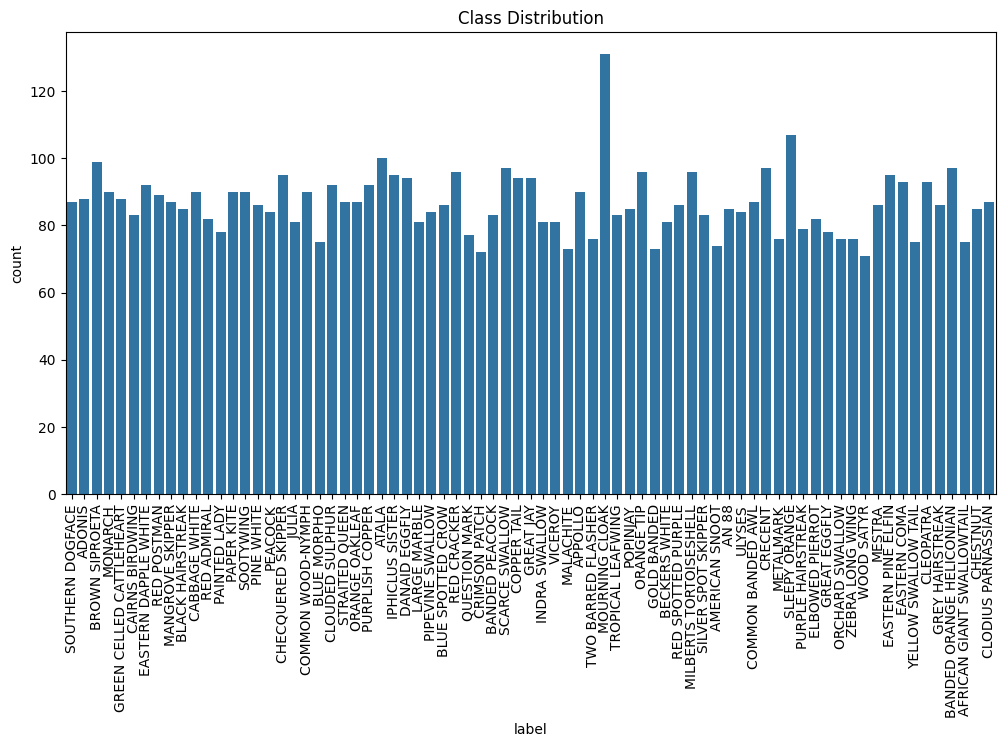

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(data=train_df, x='label')
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

**Sample image visualization**

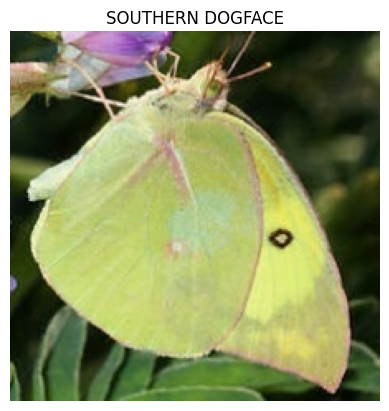

In [17]:
sample_path = DATASET_PATH + "/train/" + train_df.iloc[0]['filename']

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(train_df.iloc[0]['label'])
plt.axis("off")
plt.show()

**PREPROCESSING + AUGMENTATION**

In [18]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

**Train & Validation generators**

In [19]:
os.listdir(DATASET_PATH)

['Training_set.csv', 'Testing_set.csv', 'test', 'train']

In [20]:
train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=DATASET_PATH + "/train/",
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=DATASET_PATH + "/train/",
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

NUM_CLASSES = len(train_gen.class_indices)
print(NUM_CLASSES)
print(train_gen.class_indices)

Found 5200 validated image filenames belonging to 75 classes.
Found 1299 validated image filenames belonging to 75 classes.
75
{'ADONIS': 0, 'AFRICAN GIANT SWALLOWTAIL': 1, 'AMERICAN SNOOT': 2, 'AN 88': 3, 'APPOLLO': 4, 'ATALA': 5, 'BANDED ORANGE HELICONIAN': 6, 'BANDED PEACOCK': 7, 'BECKERS WHITE': 8, 'BLACK HAIRSTREAK': 9, 'BLUE MORPHO': 10, 'BLUE SPOTTED CROW': 11, 'BROWN SIPROETA': 12, 'CABBAGE WHITE': 13, 'CAIRNS BIRDWING': 14, 'CHECQUERED SKIPPER': 15, 'CHESTNUT': 16, 'CLEOPATRA': 17, 'CLODIUS PARNASSIAN': 18, 'CLOUDED SULPHUR': 19, 'COMMON BANDED AWL': 20, 'COMMON WOOD-NYMPH': 21, 'COPPER TAIL': 22, 'CRECENT': 23, 'CRIMSON PATCH': 24, 'DANAID EGGFLY': 25, 'EASTERN COMA': 26, 'EASTERN DAPPLE WHITE': 27, 'EASTERN PINE ELFIN': 28, 'ELBOWED PIERROT': 29, 'GOLD BANDED': 30, 'GREAT EGGFLY': 31, 'GREAT JAY': 32, 'GREEN CELLED CATTLEHEART': 33, 'GREY HAIRSTREAK': 34, 'INDRA SWALLOW': 35, 'IPHICLUS SISTER': 36, 'JULIA': 37, 'LARGE MARBLE': 38, 'MALACHITE': 39, 'MANGROVE SKIPPER': 40, 'ME

**Build Model (EfficientNetB0)**

In [21]:
base_model = EfficientNetB0(
    weights=None,
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

Classification head

In [22]:
model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

**Compile Model**

In [23]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

**Train model**

In [25]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.0152 - loss: 4.3178 - val_accuracy: 0.0216 - val_loss: 4.3173 - learning_rate: 0.0010
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.0198 - loss: 4.3160 - val_accuracy: 0.0216 - val_loss: 4.3172 - learning_rate: 0.0010
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.0198 - loss: 4.3148 - val_accuracy: 0.0216 - val_loss: 4.3178 - learning_rate: 0.0010
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0215 - loss: 4.3136
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
163/163 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.0198 - loss: 4.3140 - val_accuracy: 0.0216 - val_loss: 4.3184 - learning_rate: 0.0010
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.0198 - loss: 4.3119 - val_accuracy: 0.0216 - val_loss: 4.3186 - learning_rate: 2.0000e-04
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.0198 - loss: 

**Evaluation**

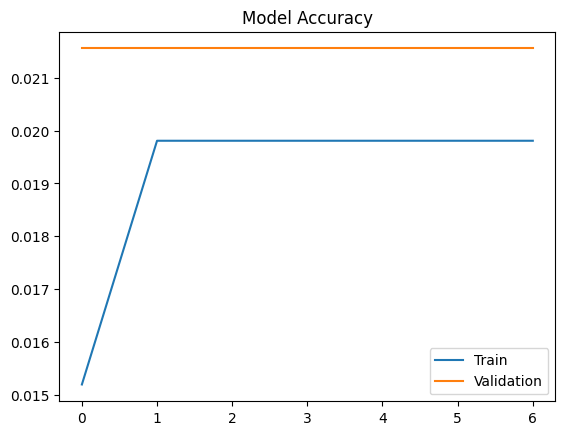

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train','Validation'])
plt.show()

Loss plot

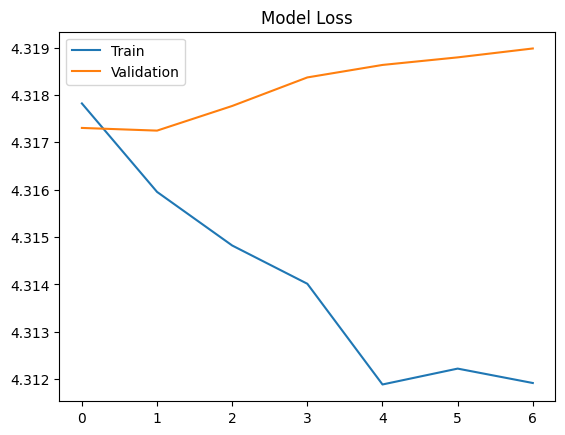

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(['Train','Validation'])
plt.show()

Confusion Matrix

41/41 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step


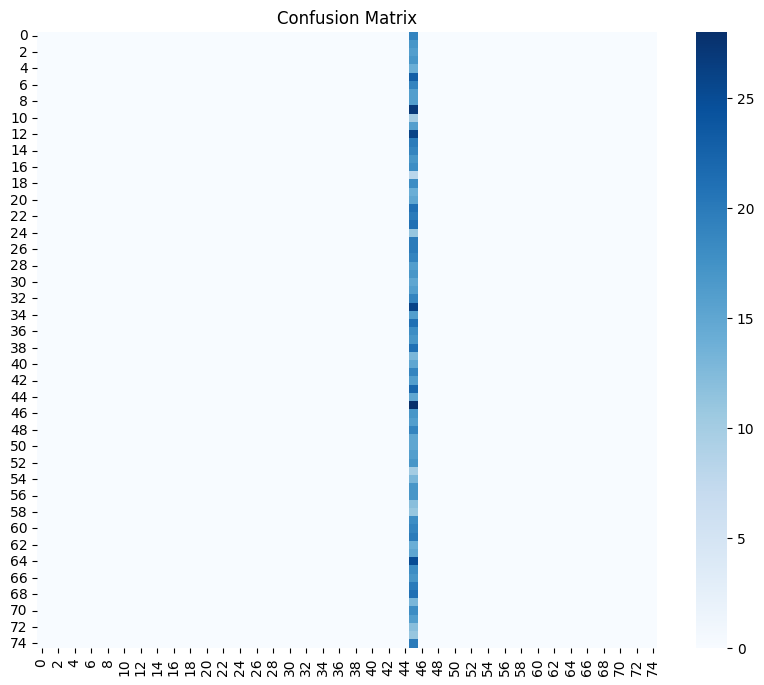

In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(val_gen.classes, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [29]:
print(classification_report(
    val_gen.classes,
    y_pred_classes,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.00      0.00      0.00        17
           2       0.00      0.00      0.00        16
           3       0.00      0.00      0.00        17
           4       0.00      0.00      0.00        14
           5       0.00      0.00      0.00        23
           6       0.00      0.00      0.00        19
           7       0.00      0.00      0.00        16
           8       0.00      0.00      0.00        16
           9       0.00      0.00      0.00        27
          10       0.00      0.00      0.00        10
          11       0.00      0.00      0.00        16
          12       0.00      0.00      0.00        26
          13       0.00      0.00      0.00        20
          14       0.00      0.00      0.00        19
          15       0.00      0.00      0.00        17
          16       0.00      0.00      0.00        18
          17       0.00    

**Single Image Prediction**

In [30]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    return np.argmax(pred)

**Save Model**

In [31]:
model.save("butterfly_model.keras")

In [32]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.0179 - loss: 4.3872 - val_accuracy: 0.0216 - val_loss: 4.3172 - learning_rate: 1.0000e-05
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.0162 - loss: 4.3529 - val_accuracy: 0.0216 - val_loss: 4.3172 - learning_rate: 1.0000e-05
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.0183 - loss: 4.3361 - val_accuracy: 0.0216 - val_loss: 4.3168 - learning_rate: 1.0000e-05
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.0194 - loss: 4.3303 - val_accuracy: 0.0146 - val_loss: 4.3224 - learning_rate: 1.0000e-05
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.0219 - loss: 4.3226 - val_accuracy: 0.0092 - val_loss: 4.3766 - learning_rate: 1.0000e-05


In [33]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'butterfly_model.keras']


In [35]:
print(train_gen.class_indices)

{'ADONIS': 0, 'AFRICAN GIANT SWALLOWTAIL': 1, 'AMERICAN SNOOT': 2, 'AN 88': 3, 'APPOLLO': 4, 'ATALA': 5, 'BANDED ORANGE HELICONIAN': 6, 'BANDED PEACOCK': 7, 'BECKERS WHITE': 8, 'BLACK HAIRSTREAK': 9, 'BLUE MORPHO': 10, 'BLUE SPOTTED CROW': 11, 'BROWN SIPROETA': 12, 'CABBAGE WHITE': 13, 'CAIRNS BIRDWING': 14, 'CHECQUERED SKIPPER': 15, 'CHESTNUT': 16, 'CLEOPATRA': 17, 'CLODIUS PARNASSIAN': 18, 'CLOUDED SULPHUR': 19, 'COMMON BANDED AWL': 20, 'COMMON WOOD-NYMPH': 21, 'COPPER TAIL': 22, 'CRECENT': 23, 'CRIMSON PATCH': 24, 'DANAID EGGFLY': 25, 'EASTERN COMA': 26, 'EASTERN DAPPLE WHITE': 27, 'EASTERN PINE ELFIN': 28, 'ELBOWED PIERROT': 29, 'GOLD BANDED': 30, 'GREAT EGGFLY': 31, 'GREAT JAY': 32, 'GREEN CELLED CATTLEHEART': 33, 'GREY HAIRSTREAK': 34, 'INDRA SWALLOW': 35, 'IPHICLUS SISTER': 36, 'JULIA': 37, 'LARGE MARBLE': 38, 'MALACHITE': 39, 'MANGROVE SKIPPER': 40, 'MESTRA': 41, 'METALMARK': 42, 'MILBERTS TORTOISESHELL': 43, 'MONARCH': 44, 'MOURNING CLOAK': 45, 'ORANGE OAKLEAF': 46, 'ORANGE TI

In [40]:
import json

with open("class_indices.json", "w") as f:
    json.dump(train_gen.class_indices, f)

